In [2]:
!pip install prophet xgboost scikit-learn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet          # for time-series model
from xgboost import XGBRegressor     # for ML model
from sklearn.metrics import mean_absolute_percentage_error

plt.rcParams['figure.figsize'] = (12, 5)

# 👉 change the file name if needed
df = pd.read_csv("savoryroot_store_sales.csv")

# convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

print(df.head())
print(df.columns)


        Date                   Store Retailer                          SKU  \
0 2024-01-01  Mumbai Store - Central    DMart  Heritage Grains Muesli 500g   
1 2024-01-01  Mumbai Store - Central    DMart   Heritage Grains Muesli 1kg   
2 2024-01-01  Mumbai Store - Central    DMart           ProGut Yogurt 100g   
3 2024-01-01  Mumbai Store - Central    DMart           ProGut Yogurt 250g   
4 2024-01-01  Mumbai Store - Central    DMart  Artisanal Bakery Toast 200g   

   Units_Sold  
0          95  
1          50  
2         110  
3          71  
4         112  
Index(['Date', 'Store', 'Retailer', 'SKU', 'Units_Sold'], dtype='object')


In [4]:
# STEP 2: Filter for one Store + SKU

store = "Mumbai Store - Central"
sku = "Heritage Grains Muesli 1kg"

data = df[(df['Store'] == store) & (df['SKU'] == sku)].copy()
data = data[['Date', 'Units_Sold']]

# Rename columns for Prophet
data = data.rename(columns={"Date": "ds", "Units_Sold": "y"})

# Sort by date
data = data.sort_values("ds")

data.head()

,ds,y
1,2024-01-01,50
12,2024-01-01,50
408,2024-01-02,50
419,2024-01-02,50
815,2024-01-03,50


In [5]:
# STEP 3: Prophet forecasting

model = Prophet()
model.fit(data)

# Create future dates (next 30 days)
future = model.make_future_dataframe(periods=30)

# Predict future sales
forecast = model.predict(future)

# Show results
forecast[['ds', 'yhat']].tail(10)


00:34:17 - cmdstanpy - INFO - Chain [1] start processing
00:34:18 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
202,2024-07-21,133.651738
203,2024-07-22,108.502095
204,2024-07-23,109.618696
205,2024-07-24,109.910505
206,2024-07-25,107.459320
207,2024-07-26,123.767918
208,2024-07-27,135.223648
209,2024-07-28,135.630791
210,2024-07-29,110.481148
211,2024-07-30,111.597749


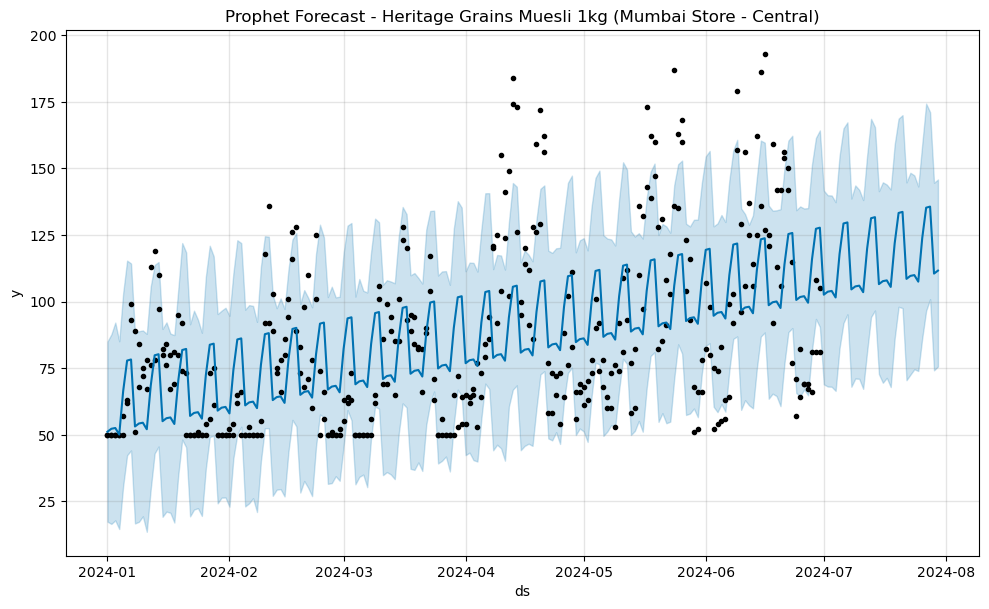

In [6]:
model.plot(forecast)
plt.title(f"Prophet Forecast - {sku} ({store})")
plt.show()


In [7]:
from sklearn.metrics import mean_absolute_percentage_error

# STEP 5: Train/Test split
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]

# Train Prophet on train data
model_train = Prophet()
model_train.fit(train)

# Forecast for the test period
future_test = model_train.make_future_dataframe(periods=len(test))
forecast_test = model_train.predict(future_test)

# Extract only test predictions (same length)
pred = forecast_test[['ds', 'yhat']].iloc[-len(test):]
pred['y_true'] = test['y'].values

# Calculate MAPE
mape = mean_absolute_percentage_error(pred['y_true'], pred['yhat']) * 100
print("MAPE (%): ", round(mape, 2))


00:35:50 - cmdstanpy - INFO - Chain [1] start processing
00:35:50 - cmdstanpy - INFO - Chain [1] done processing


MAPE (%):  40.25


In [8]:
import numpy as np
from xgboost import XGBRegressor

# STEP 6: Feature Engineering
data_ml = data.copy()
data_ml['day_of_week'] = data_ml['ds'].dt.dayofweek
data_ml['month'] = data_ml['ds'].dt.month
data_ml['is_weekend'] = data_ml['day_of_week'].isin([5,6]).astype(int)

# Train/Test split
train_ml = data_ml.iloc[:train_size]
test_ml = data_ml.iloc[train_size:]

X_train = train_ml[['day_of_week','month','is_weekend']]
y_train = train_ml['y']

X_test = test_ml[['day_of_week','month','is_weekend']]
y_test = test_ml['y']

# Train XGBoost model
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
model_xgb.fit(X_train, y_train)

# Predict test period
y_pred_xgb = model_xgb.predict(X_test)

# XGBoost MAPE
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
print("XGBoost MAPE (%): ", round(mape_xgb, 2))


XGBoost MAPE (%):  31.67


In [9]:
# STEP 7: Create future dataframe for ML model
future_30 = future.tail(30).copy()
future_30['day_of_week'] = future_30['ds'].dt.dayofweek
future_30['month'] = future_30['ds'].dt.month
future_30['is_weekend'] = future_30['day_of_week'].isin([5,6]).astype(int)

# XGBoost future prediction
xgb_pred_future = model_xgb.predict(future_30[['day_of_week','month','is_weekend']])

# Prophet future prediction (already in forecast['yhat'])
prophet_pred_future = forecast[['yhat']].tail(30).values.flatten()

# Hybrid
hybrid_forecast = (prophet_pred_future + xgb_pred_future) / 2

future_30['Hybrid_Pred'] = hybrid_forecast

future_30[['ds', 'Hybrid_Pred']].head()


,ds,Hybrid_Pred
182,2024-07-01,92.199082
183,2024-07-02,92.007573
184,2024-07-03,96.174245
185,2024-07-04,95.261061
186,2024-07-05,118.665070


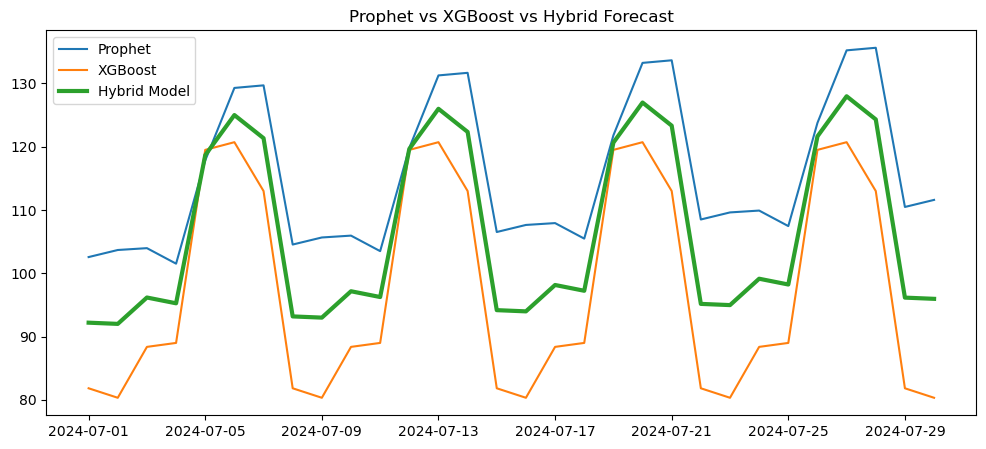

In [10]:
plt.figure(figsize=(12,5))
plt.plot(future_30['ds'], prophet_pred_future, label="Prophet")
plt.plot(future_30['ds'], xgb_pred_future, label="XGBoost")
plt.plot(future_30['ds'], hybrid_forecast, label="Hybrid Model", linewidth=3)
plt.legend()
plt.title("Prophet vs XGBoost vs Hybrid Forecast")
plt.show()

In [11]:
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor

FORECAST_HORIZON = 30  # days

def forecast_store_sku(df, store, sku, horizon=FORECAST_HORIZON):
    # 1) Filter data
    sub = df[(df['Store'] == store) & (df['SKU'] == sku)].copy()
    if sub.empty:
        return None  # no data for this combo

    sub = sub[['Date', 'Units_Sold']].rename(columns={'Date': 'ds', 'Units_Sold': 'y'})
    sub = sub.sort_values('ds')

    # basic safety: need enough history
    if len(sub) < 40:
        return None

    # 2) Prophet model on full history
    m_prophet = Prophet()
    m_prophet.fit(sub)

    future = m_prophet.make_future_dataframe(periods=horizon)
    fc_prophet = m_prophet.predict(future)

    # 3) XGBoost on features
    data_ml = sub.copy()
    data_ml['day_of_week'] = data_ml['ds'].dt.dayofweek
    data_ml['month'] = data_ml['ds'].dt.month
    data_ml['is_weekend'] = data_ml['day_of_week'].isin([5, 6]).astype(int)

    train_size = int(len(data_ml) * 0.8)
    if len(data_ml) - train_size < 7:
        return None  # not enough test points

    train_ml = data_ml.iloc[:train_size]

    X_train = train_ml[['day_of_week', 'month', 'is_weekend']]
    y_train = train_ml['y']

    model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
    model_xgb.fit(X_train, y_train)

    # future features for ML
    future_h = future.tail(horizon).copy()
    future_h['day_of_week'] = future_h['ds'].dt.dayofweek
    future_h['month'] = future_h['ds'].dt.month
    future_h['is_weekend'] = future_h['day_of_week'].isin([5, 6]).astype(int)

    xgb_pred = model_xgb.predict(future_h[['day_of_week', 'month', 'is_weekend']])
    prophet_pred = fc_prophet[['yhat']].tail(horizon).values.flatten()

    hybrid_pred = (xgb_pred + prophet_pred) / 2

    # 4) Build result table
    result = pd.DataFrame({
        'Store': store,
        'SKU': sku,
        'Date': future_h['ds'].values,
        'Prophet_Pred': prophet_pred,
        'XGB_Pred': xgb_pred,
        'Hybrid_Pred': hybrid_pred
    })

    return result


In [12]:
test_forecast = forecast_store_sku(
    df=df,
    store="Mumbai Store - Central",
    sku="Heritage Grains Muesli 1kg",
    horizon=30
)

test_forecast.head()


00:42:08 - cmdstanpy - INFO - Chain [1] start processing
00:42:08 - cmdstanpy - INFO - Chain [1] done processing


,Store,SKU,Date,Prophet_Pred,XGB_Pred,Hybrid_Pred
0,Mumbai Store - Central,Heritage Grains Muesli 1kg,2024-07-01,102.564935,81.833229,92.199082
1,Mumbai Store - Central,Heritage Grains Muesli 1kg,2024-07-02,103.681536,80.333611,92.007573
2,Mumbai Store - Central,Heritage Grains Muesli 1kg,2024-07-03,103.973345,88.375145,96.174245
3,Mumbai Store - Central,Heritage Grains Muesli 1kg,2024-07-04,101.522160,88.999962,95.261061
4,Mumbai Store - Central,Heritage Grains Muesli 1kg,2024-07-05,117.830758,119.499382,118.665070


In [13]:
# STEP 10: Get list of all Store + SKU combinations
store_sku_pairs = df[['Store', 'SKU']].drop_duplicates().values.tolist()

all_forecasts = []  # store results

for store, sku in store_sku_pairs:
    print(f"Processing: {store} | {sku}")
    fc = forecast_store_sku(df, store, sku)
    if fc is not None:
        all_forecasts.append(fc)

# Combine all forecasts into 1 dataframe
final_forecast_df = pd.concat(all_forecasts, ignore_index=True)

print("Total forecast rows:", len(final_forecast_df))
final_forecast_df.head()


Processing: Mumbai Store - Central | Heritage Grains Muesli 500g


00:42:51 - cmdstanpy - INFO - Chain [1] start processing
00:42:51 - cmdstanpy - INFO - Chain [1] done processing


Processing: Mumbai Store - Central | Heritage Grains Muesli 1kg


00:42:52 - cmdstanpy - INFO - Chain [1] start processing
00:42:52 - cmdstanpy - INFO - Chain [1] done processing
00:42:52 - cmdstanpy - INFO - Chain [1] start processing


Processing: Mumbai Store - Central | ProGut Yogurt 100g


...

00:45:06 - cmdstanpy - INFO - Chain [1] start processing


Processing: Ahilyanagar Store | Cold-Pressed Virgin Olive Oil 500ml


00:45:06 - cmdstanpy - INFO - Chain [1] done processing


Processing: Ahilyanagar Store | Cold-Pressed Virgin Olive Oil 1L
Total forecast rows: 6930


,Store,SKU,Date,Prophet_Pred,XGB_Pred,Hybrid_Pred
0,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-01,188.796082,157.500000,173.148041
1,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-02,189.505884,150.000351,169.753117
2,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-03,187.411011,174.249985,180.830498
3,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-04,187.275402,167.624802,177.450102
4,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-05,214.704740,206.999695,210.852217


In [14]:
print(len(all_forecasts))

231


In [15]:
if len(all_forecasts) > 0:
    display(all_forecasts[0].head())
else:
    print("No forecasts returned")


,Store,SKU,Date,Prophet_Pred,XGB_Pred,Hybrid_Pred
0,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-01,188.796082,157.500000,173.148041
1,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-02,189.505884,150.000351,169.753117
2,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-03,187.411011,174.249985,180.830498
3,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-04,187.275402,167.624802,177.450102
4,Mumbai Store - Central,Heritage Grains Muesli 500g,2024-07-05,214.704740,206.999695,210.852217


In [16]:
# Save forecast output to Excel & CSV
final_forecast_df.to_excel("Hybrid_Forecast_Store_SKU_30Days.xlsx", index=False)
final_forecast_df.to_csv("Hybrid_Forecast_Store_SKU_30Days.csv", index=False)

print("Files saved successfully!")


Files saved successfully!


In [17]:
import os
import matplotlib.pyplot as plt

# create folder to save charts
os.makedirs("forecast_charts", exist_ok=True)
print("Folder 'forecast_charts' is ready.")

Folder 'forecast_charts' is ready.


In [18]:
# STEP 2: Plot and save chart per Store+SKU

unique_pairs = final_forecast_df[['Store', 'SKU']].drop_duplicates().values.tolist()

for store, sku in unique_pairs:
    # Historical data
    hist = df[(df['Store'] == store) & (df['SKU'] == sku)].copy()
    hist = hist[['Date', 'Units_Sold']].sort_values('Date')

    # Forecast data
    fc = final_forecast_df[(final_forecast_df['Store'] == store) & (final_forecast_df['SKU'] == sku)].copy()
    fc = fc[['Date', 'Hybrid_Pred']].sort_values('Date')

    if hist.empty or fc.empty:
        continue  # skip if something is missing

    plt.figure(figsize=(12,5))

    # plot actuals
    plt.plot(hist['Date'], hist['Units_Sold'], label='Actual Sales')

    # plot forecast
    plt.plot(fc['Date'], fc['Hybrid_Pred'], label='Hybrid Forecast (30 days)', linestyle='--')

    plt.title(f"{sku} - {store}")
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.tight_layout()

    # safe filename
    safe_store = store.replace(" ", "_").replace("/", "_")
    safe_sku = sku.replace(" ", "_").replace("/", "_")
    filename = f"forecast_charts/{safe_store}__{safe_sku}.png"

    plt.savefig(filename)
    plt.close()

print("Charts saved in 'forecast_charts' folder.")


Charts saved in 'forecast_charts' folder.
